In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/abulbasar/data/refs/heads/master/credit-default.csv")
df

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,property,age,installment_plan,housing,existing_credits,default,dependents,telephone,foreign_worker,job
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,...,real estate,67,none,own,2,1,1,yes,yes,skilled employee
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,...,real estate,22,none,own,1,2,1,none,yes,skilled employee
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,...,real estate,49,none,own,1,1,2,none,yes,unskilled resident
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,...,building society savings,45,none,for free,1,1,2,none,yes,skilled employee
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,...,unknown/none,53,none,for free,2,2,2,none,yes,skilled employee
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,unknown,12,repaid,furniture,1736,< 100 DM,4 - 7 yrs,3,female,none,...,real estate,31,none,own,1,1,1,none,yes,unskilled resident
996,< 0 DM,30,repaid,car (used),3857,< 100 DM,1 - 4 yrs,4,divorced male,none,...,building society savings,40,none,own,1,1,1,yes,yes,mangement self-employed
997,unknown,12,repaid,radio/tv,804,< 100 DM,> 7 yrs,4,single male,none,...,other,38,none,own,1,1,1,none,yes,skilled employee
998,< 0 DM,45,repaid,radio/tv,1845,< 100 DM,1 - 4 yrs,4,single male,none,...,unknown/none,23,none,for free,1,2,1,yes,yes,skilled employee


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   checking_balance      1000 non-null   str  
 1   months_loan_duration  1000 non-null   int64
 2   credit_history        1000 non-null   str  
 3   purpose               1000 non-null   str  
 4   amount                1000 non-null   int64
 5   savings_balance       1000 non-null   str  
 6   employment_length     1000 non-null   str  
 7   installment_rate      1000 non-null   int64
 8   personal_status       1000 non-null   str  
 9   other_debtors         1000 non-null   str  
 10  residence_history     1000 non-null   int64
 11  property              1000 non-null   str  
 12  age                   1000 non-null   int64
 13  installment_plan      1000 non-null   str  
 14  housing               1000 non-null   str  
 15  existing_credits      1000 non-null   int64
 16  default           

In [4]:
target = "default"

In [7]:
X = df.drop(columns=[target])
X

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,residence_history,property,age,installment_plan,housing,existing_credits,dependents,telephone,foreign_worker,job
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,4,real estate,67,none,own,2,1,yes,yes,skilled employee
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,2,real estate,22,none,own,1,1,none,yes,skilled employee
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,3,real estate,49,none,own,1,2,none,yes,unskilled resident
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,4,building society savings,45,none,for free,1,2,none,yes,skilled employee
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,4,unknown/none,53,none,for free,2,2,none,yes,skilled employee
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,unknown,12,repaid,furniture,1736,< 100 DM,4 - 7 yrs,3,female,none,4,real estate,31,none,own,1,1,none,yes,unskilled resident
996,< 0 DM,30,repaid,car (used),3857,< 100 DM,1 - 4 yrs,4,divorced male,none,4,building society savings,40,none,own,1,1,yes,yes,mangement self-employed
997,unknown,12,repaid,radio/tv,804,< 100 DM,> 7 yrs,4,single male,none,4,other,38,none,own,1,1,none,yes,skilled employee
998,< 0 DM,45,repaid,radio/tv,1845,< 100 DM,1 - 4 yrs,4,single male,none,4,unknown/none,23,none,for free,1,1,yes,yes,skilled employee


In [8]:
y = df[target]
y

0      1
1      2
2      1
3      1
4      2
      ..
995    1
996    1
997    1
998    2
999    1
Name: default, Length: 1000, dtype: int64

In [10]:
y.value_counts() # 1: not defaulted, 2: defaulted

default
1    700
2    300
Name: count, dtype: int64

In [11]:
X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
X

,months_loan_duration,amount,installment_rate,residence_history,age,existing_credits,dependents,checking_balance_< 0 DM,checking_balance_> 200 DM,checking_balance_unknown,...,property_unknown/none,installment_plan_none,installment_plan_stores,housing_own,housing_rent,telephone_yes,foreign_worker_yes,job_skilled employee,job_unemployed non-resident,job_unskilled resident
0,6,1169,4,4,67,2,1,True,False,False,...,False,True,False,True,False,True,True,True,False,False
1,48,5951,2,2,22,1,1,False,False,False,...,False,True,False,True,False,False,True,True,False,False
2,12,2096,2,3,49,1,2,False,False,True,...,False,True,False,True,False,False,True,False,False,True
3,42,7882,2,4,45,1,2,True,False,False,...,False,True,False,False,False,False,True,True,False,False
4,24,4870,3,4,53,2,2,True,False,False,...,True,True,False,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,12,1736,3,4,31,1,1,False,False,True,...,False,True,False,True,False,False,True,False,False,True
996,30,3857,4,4,40,1,1,True,False,False,...,False,True,False,True,False,True,True,False,False,False
997,12,804,4,4,38,1,1,False,False,True,...,False,True,False,True,False,False,True,True,False,False
998,45,1845,4,4,23,1,1,True,False,False,...,True,True,False,False,False,True,True,True,False,False


In [12]:
target = "default"
y = df[target]
X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
y

0      1
1      2
2      1
3      1
4      2
      ..
995    1
996    1
997    1
998    2
999    1
Name: default, Length: 1000, dtype: int64

In [13]:
from sklearn import preprocessing

In [14]:
target = "default"
y = df[target]
X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
le = preprocessing.LabelEncoder()
y = le.fit_transform(y)
y

array([0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,

In [23]:
from sklearn import model_selection, linear_model
target = "default"
y = df[target]
X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
le = preprocessing.LabelEncoder()
y = le.fit_transform(y)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=123)

scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


est = linear_model.LogisticRegression()
est.fit(X_train, y_train) # train the model
y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

pd.DataFrame({"y": y_test, "y_pred": y_test_pred})

,y,y_pred
0,1,1
1,1,0
2,0,0
3,1,1
4,0,0
...,...,...
295,1,1
296,1,0
297,0,1
298,0,1


In [32]:
from sklearn import model_selection, linear_model
target = "default"
y = df[target]
X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
le = preprocessing.LabelEncoder()
y = le.fit_transform(y)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=123)

scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


est = linear_model.LogisticRegression()
est.fit(X_train, y_train) # train the model
y_train_prob = est.predict_proba(X_train)
y_test_prob = est.predict_proba(X_test)

#pd.DataFrame({"y": y_test, "y_pred": y_train_prob})

In [33]:
y_test_prob.shape

(300, 2)

In [34]:
y_test.shape

(300,)

In [37]:
y_test_prob[:5]

array([[0.14466438, 0.85533562],
       [0.99013483, 0.00986517],
       [0.6721505 , 0.3278495 ],
       [0.3423931 , 0.6576069 ],
       [0.9467974 , 0.0532026 ]])

In [43]:
from sklearn import model_selection, linear_model
import numpy as np
target = "default"
y = df[target]
X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
le = preprocessing.LabelEncoder()
y = le.fit_transform(y)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=123)

scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


est = linear_model.LogisticRegression()
est.fit(X_train, y_train) # train the model
y_train_prob = est.predict_proba(X_train)[:, 1]
y_test_prob = est.predict_proba(X_test)[:, 1]

pd.DataFrame({"y": y_test, "y_prob": y_test_prob, "y_pred": np.where(y_test_prob>0.5, 1, 0)})

,y,y_prob,y_pred
0,1,0.855336,1
1,1,0.009865,0
2,0,0.327850,0
3,1,0.657607,1
4,0,0.053203,0
...,...,...,...
295,1,0.670571,1
296,1,0.089390,0
297,0,0.554662,1
298,0,0.562391,1


In [44]:
from sklearn import metrics

In [45]:
metrics.confusion_matrix(y_test, y_test_pred)


array([[168,  32],
       [ 42,  58]])

In [64]:
from sklearn import model_selection, linear_model
import numpy as np


def find_metrics(threshold):
    target = "default"
    y = df[target]
    X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
    le = preprocessing.LabelEncoder()
    y = le.fit_transform(y)
    X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=123)
    
    scaler = preprocessing.StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    
    est = linear_model.LogisticRegression()
    est.fit(X_train, y_train) # train the model
    
    y_train_prob = est.predict_proba(X_train)[:, 1]
    y_test_prob = est.predict_proba(X_test)[:, 1]
    y_test_pred = np.where(y_test_prob>threshold, 1, 0)
    y_train_prob = est.predict_proba(X_train)[:, 1]
    y_train_pred = np.where(y_train_prob>threshold, 1, 0)
    
    
    pd.DataFrame({"y": y_test, "y_prob": y_test_prob, "y_pred": y_test_pred})
    
    metrics.confusion_matrix(y_test, y_test_pred)

    print("threhsold: ", threshold)
    print("train accuracy: ", metrics.accuracy_score(y_train, y_train_pred))
    print("train precision: ", metrics.precision_score(y_train, y_train_pred))
    print("train recall: ", metrics.recall_score(y_train, y_train_pred))
    print("train f1: ", metrics.f1_score(y_train, y_train_pred))
    
    print("test accuracy: ", metrics.accuracy_score(y_test, y_test_pred))
    print("test precision: ", metrics.precision_score(y_test, y_test_pred))
    print("test recall: ", metrics.recall_score(y_test, y_test_pred))
    print("test f1: ", metrics.f1_score(y_test, y_test_pred))
    print(metrics.confusion_matrix(y_test, y_test_pred))

find_metrics(0.5)

threhsold:  0.5
train accuracy:  0.7928571428571428
train precision:  0.6923076923076923
train recall:  0.495
train f1:  0.577259475218659
test accuracy:  0.7533333333333333
test precision:  0.6444444444444445
test recall:  0.58
test f1:  0.6105263157894737
[[168  32]
 [ 42  58]]


In [48]:
metrics.accuracy_score(y_test, y_test_pred)

0.6866666666666666

In [49]:
metrics.precision_score(y_test, y_test_pred)

0.5176470588235295

In [50]:
metrics.recall_score(y_test, y_test_pred)

0.88

In [65]:
find_metrics(0.5)

threhsold:  0.5
train accuracy:  0.7928571428571428
train precision:  0.6923076923076923
train recall:  0.495
train f1:  0.577259475218659
test accuracy:  0.7533333333333333
test precision:  0.6444444444444445
test recall:  0.58
test f1:  0.6105263157894737
[[168  32]
 [ 42  58]]


In [66]:
find_metrics(0.3)

threhsold:  0.3
train accuracy:  0.7471428571428571
train precision:  0.5421245421245421
train recall:  0.74
train f1:  0.6257928118393234
test accuracy:  0.7433333333333333
test precision:  0.5864661654135338
test recall:  0.78
test f1:  0.6695278969957081
[[145  55]
 [ 22  78]]


In [67]:
find_metrics(0.8)

threhsold:  0.8
train accuracy:  0.7414285714285714
train precision:  0.8518518518518519
train recall:  0.115
train f1:  0.2026431718061674
test accuracy:  0.72
test precision:  0.8076923076923077
test recall:  0.21
test f1:  0.3333333333333333
[[195   5]
 [ 79  21]]


<Axes: >

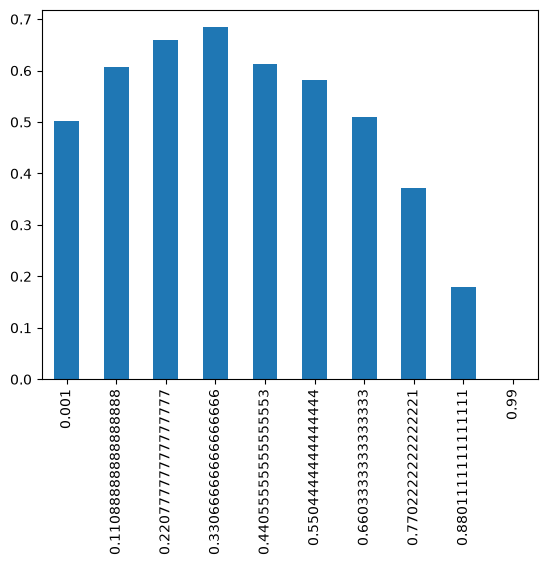

In [70]:
def f1(threshold):
    target = "default"
    y = df[target]
    X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
    le = preprocessing.LabelEncoder()
    y = le.fit_transform(y)
    X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=123)
    
    scaler = preprocessing.StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    
    est = linear_model.LogisticRegression()
    est.fit(X_train, y_train) # train the model
    
    y_train_prob = est.predict_proba(X_train)[:, 1]
    y_test_prob = est.predict_proba(X_test)[:, 1]
    y_test_pred = np.where(y_test_prob>threshold, 1, 0)
    y_train_prob = est.predict_proba(X_train)[:, 1]
    y_train_pred = np.where(y_train_prob>threshold, 1, 0)
    
    
    return metrics.f1_score(y_test, y_test_pred)

scores = dict()
for t in np.linspace(0.001, 0.99, 10):
    scores[t] = f1(t)
pd.Series(scores).plot.bar()